In [1]:
import scanpy as sc
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import glob
import os

In [2]:
got_adata = sc.read_10x_mtx('../data/GSM3309837_species_mix_hg38', var_names='gene_symbols', cache=True, make_unique=True)
got_adata.var.index = got_adata.var.index.str.replace('hg38_','')

sc.pp.calculate_qc_metrics(got_adata, inplace = True)


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/readwrite.py:572: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['hg38_SNORD116-1', 'hg38_SNORD116-2', 'hg38_SNORD116-3', 'hg38_SNORD116-4', 'hg38_SNORD116-5']
  adata = _read_10x_mtx(


In [ ]:
## read in original cellranger output for raw counts across all genes
data_dir = large_data_dir + 'cr_CL_mega_sample_filtered_feature_bc_matrix.h5'
gift_adata = sc.read_10x_h5(data_dir)

## then read processed annotation and subset to HeLa
gift_adata.obs['cell_type'] = sc.read_h5ad(large_data_dir + 'CL_mega_WTA.h5ad').obs['cell_type']
gift_adata = gift_adata[gift_adata.obs['cell_type'] == 'HeLa'].copy()

sc.pp.calculate_qc_metrics(gift_adata, inplace = True)


In [4]:
adata = sc.concat([gift_adata, got_adata], label='platform', keys=['GIFT', 'GoT'], join='inner', index_unique=None)
sc.pp.calculate_qc_metrics(adata, inplace = True)

min_counts = 1000
min_genes = 500

print(len(adata))
sc.pp.filter_cells(adata,min_counts=min_counts)
sc.pp.filter_cells(adata,min_genes=min_genes)
print(len(adata))


5072
5072


14537.0
23004.0


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3012004/602068394.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())


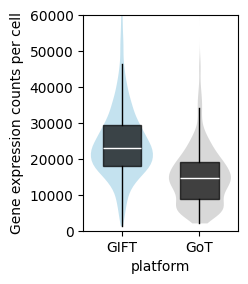

In [5]:
fig, ax = plt.subplots(figsize=(2,2.8))

to_plot = 'total_counts'

palette = {'GIFT':'#27aae1', 'GoT':'grey'}
sc.pl.violin(adata, keys=to_plot, groupby='platform', ax=ax, show=False, alpha=0.3, jitter=False, inner='box', palette=palette, linewidth=0, stripplot=False)
ax.set_xticklabels(ax.get_xticklabels())
for i, platform in enumerate(['GIFT', 'GoT']):
    data = adata[adata.obs['platform'] == platform].obs[to_plot]
    bp = ax.boxplot([data], positions=[i], widths=0.5, showfliers=False, 
                     patch_artist=True, boxprops=dict(facecolor='k', alpha=0.7),
                     medianprops=dict(color='white', linewidth=1),
                     capprops=dict(linewidth=0))
    
ax.set_ylim(0,60000)
ax.set_ylabel('Gene expression counts per cell')

print(adata[adata.obs['platform'] == 'GoT'].obs[to_plot].median())
print(adata[adata.obs['platform'] == 'GIFT'].obs[to_plot].median())

plt.savefig('../plots/GIFT_vs_GoT_WTA_counts.pdf', bbox_inches='tight')

In [6]:
## check n cells for each platform
adata.obs['platform'].value_counts()

platform
GIFT    4409
GoT      663
Name: count, dtype: int64

In [7]:
## check number of genes included
len(adata.var)

17225